<a href="https://colab.research.google.com/github/talestrom/Dimensionality_Reduction_in_Action/blob/main/Dimensionality_Reduction_in_Action.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Examples of extremely high-dimensional datasets

*   Images (pixels)
*   Textual (embedding coordinates)
*   Genomics (genes)
*   Audio (time samples)





# Plan of the tutorial


1. Curse of dimensionality - and how it affects clustering of high-dimensional data

  *   distribution of distances in high-dimension looses its importance
  *   the nearest neighbor is almost as far as the farthest

2. Random projections

*   low computational way to preserve distances after reducing dimensions
*   project to an extremely low dimension, disrupt distance structure, reveal hidden groupings as clusters in low dimensions


3. Linear reduction - easy to interpret

  *   eigenvectors identify the direction where the data is spread out the most

4. Complex non-linear reductions

  *  neural network that encodes and subsequently decodes high-dimensional data.
  *  use the encoder to reduce dimensionality

5. Non-linear mappings useful for visualization

  * preserve local and global structure combining several low-dimensional manifolds


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Curse of dimensionality and how it affects clustering

Clusters do not have one precise definition, but intuitively we are looking for groups of points that are concentrated close together: points inside one cluster should be closer to each other than to points in other clusters.

For example in case of a well known Iris dataset we can see how the points in the first class separate from the points in the second class based on two dimensions ("Sepal length" and "Petal length") out of the available four diemnsions.

Iris dataset was first published in: Fisher, R. A. (1936). The use of multiple measurements in taxonomic problems.
Annals of Eugenics, 7(2), 179–188. We access it through scikit-learn.

In [2]:
from sklearn import datasets
iris = datasets.load_iris()
X_iris = iris.data
y_iris = iris.target

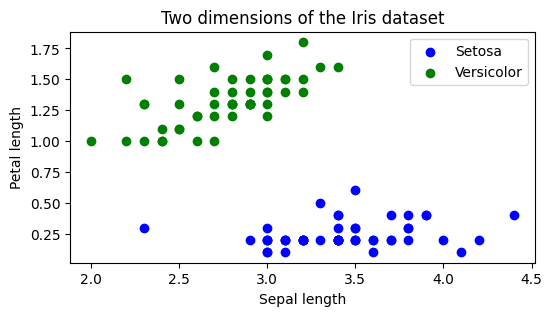

In [3]:
#visualize the Iris dataset:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 3))
mask0 = y_iris == 0
mask1 = y_iris == 1

plt.scatter(X_iris[mask0,1], X_iris[mask0,3], c='blue', label='Setosa')
plt.scatter(X_iris[mask1,1], X_iris[mask1,3], c='green', label='Versicolor')

plt.xlabel("Sepal length")
plt.ylabel("Petal length")
plt.title("Two dimensions of the Iris dataset")
plt.legend()

plt.show()

However, for high-dimensional datasets (with 10 and more dimensions), we can not always rely on such clusters of nearby points being present, even for data that are not structureless.  

For a wide range of distributions distances between points in high dimensions loose their significance: the distance to the nearest data point approaches the distance to the farthest data point.

For example if we consider $n$ datapoints $\{x_i\}_{i=1}^n$ and distances from these points to another datapoint $q$ then the maximum of those distances converges to the minimum of the distances in probability: for all $\varepsilon>0$

$$\lim_{d \to \infty}P\left(d_{max}(d) \leq (1+\varepsilon)d_{min}(d)\right) = 1. $$

See a paper by Kevin Beyer, Jonathan Goldstein, Raghu Ramakrishnan and Uri Shaft
"When is nearest neighbor useful?" (https://link.springer.com/chapter/10.1007/3-540-49257-7_15).

### Distances between points in Gaussian data.

 Let us see if we can observe that in Gaussian data the farthest distance becomes close to the nearest distance via a plot of the ratio.    

In [4]:
# we need a function to measure dist_max and dist_min
# of a given point to all the points in the dataset:
def dist_max_min(data, point):
  n_samples = data.shape[0]
  distances = np.zeros(n_samples)
  dist_min = np.inf
  dist_max = -np.inf
  for i in range(n_samples):
    distance = np.linalg.norm(data[i,:] - point)
    dist_min = min(dist_min, distance)
    dist_max = max(dist_max, distance)
  return dist_min, dist_max

In [5]:
#compute ratios between distances for a growing number of dimensions (3s for 200,31s for 400)
num_trials = 200
num_samples = 100
distance_ratio = np.zeros(num_trials)
for i in range(num_trials):
  np.random.seed(17)
  point = np.random.multivariate_normal(np.zeros(i+1),np.eye(i+1),1)#random point q
  np.random.seed(18)
  data = np.random.multivariate_normal(np.zeros(i+1),np.eye(i+1), num_samples)
  dist_min, dist_max = dist_max_min(data, point)
  distance_ratio[i] = dist_max/dist_min

Let us see if the sample ratio approximately converges to 1 when dimensionality increases:

$$\lim_{d \to \infty} \frac{\hat{d}_{\text{max}}(d)}{\hat{d}_{\text{min}}(d)} = 1 ?$$


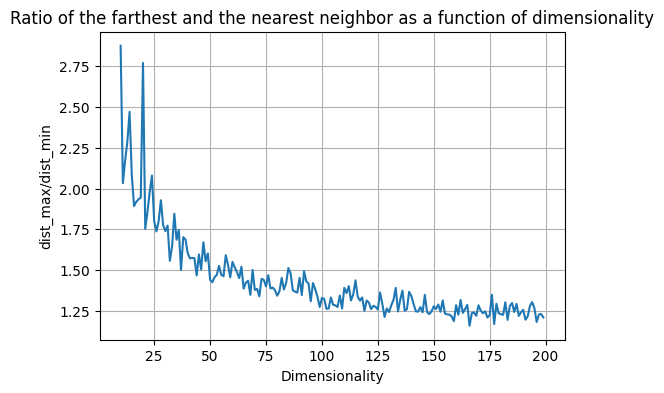

In [6]:
# plot dist_max/dist_min for different dimensionalities d:
plt.figure(figsize = (6,4))
start=10
indices = np.arange(start, len(distance_ratio)) #actual indices
plt.plot(indices, distance_ratio[start:])  # line plot with points
plt.xlabel("Dimensionality")
plt.ylabel("dist_max/dist_min")
plt.title("Ratio of the farthest and the nearest neighbor as a function of dimensionality")
plt.grid(True)
plt.show()

### Does this hold for some real data as well?

#### Olivetti dataset

The Olivetti Faces Dataset was collected at AT&T Laboratories Cambridge (1992–1994). We accesse via scikit-learn.

Dataset consists of 400 images of 40 different people (10 images per person). Images are 64x64 pixels, which flattens to 4096 dimensions.


In [7]:
# Load the Olivetti faces dataset
from sklearn.datasets import fetch_olivetti_faces
data = fetch_olivetti_faces()
#X = data.images.reshape((len(data.images), -1))
X_olivetti = data.images
y_olivetti = data.target #Y contains the number of the person who is photographed

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [8]:
print(X_olivetti.shape)

(400, 64, 64)


In [9]:
print(y_olivetti[:35])

[0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 3 3 3 3 3]


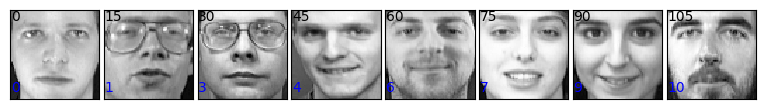

In [11]:
#visualize the dataset
import matplotlib.pyplot as plt

how_many = 8 #whole dataset has 400
fig = plt.figure(figsize=(60, 60))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for i in range(how_many):
    j=15*i #taking every 15th sample
    ax = fig.add_subplot(64, 64, i + 1, xticks=[], yticks=[])
    ax.imshow(1-X_olivetti[j], cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 58, str(y_olivetti[j]), c='blue')
    ax.text(0, 7, j)

In [12]:
#flatten the data:
X_olivetti_flat = X_olivetti.reshape((len(X_olivetti), -1))
print(X_olivetti_flat.shape)

(400, 4096)


In [16]:
#measure the distances (add one dimension each time) (4000 in 12s - 25s)
num_trials = 4096
distance_ratio = np.zeros(num_trials)
for i in range(num_trials):
  point = X_olivetti_flat[0,:i+1] #take the first datapoint as a referenced one
  data = X_olivetti_flat[1:,:i+1] #the dataset including the person from "point"
  dist_min, dist_max = dist_max_min(data, point)
  distance_ratio[i] = dist_max/dist_min

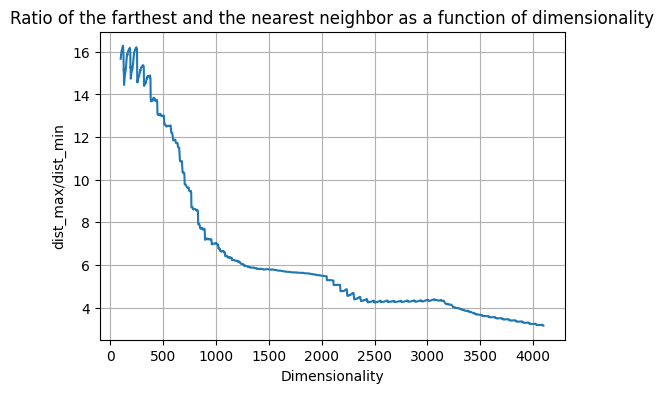

In [17]:
# plot dist_max/dist_min for different dimensionalities d:
plt.figure(figsize = (6,4))
start=100
indices = np.arange(start, len(distance_ratio)) #actual indices
plt.plot(indices, distance_ratio[start:])  # line plot with points
plt.xlabel("Dimensionality")
plt.ylabel("dist_max/dist_min")
plt.title("Ratio of the farthest and the nearest neighbor as a function of dimensionality")
plt.grid(True)
plt.show()

#### Gene Expression Omnibus dataset

Consider the high-dimensional dataset from Gene Expression Omnibus with GEO accession GSE67602 published by Joost S. et al. It contains single-cell RNA-sequences of murine epidermis and it is publicly available at https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE67602&utm_source. The dataset consists of 1422 epidermal cells (samples) that each has 26024 features representing expressions for different genes.

We can download the data from https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67602/suppl/ under the name GSE67602_Joost_et_al_expression.txt.gz that gives a zipped txt file.

In [18]:
!wget https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67602/suppl/GSE67602_Joost_et_al_expression.txt.gz

--2026-04-18 02:22:01--  https://ftp.ncbi.nlm.nih.gov/geo/series/GSE67nnn/GSE67602/suppl/GSE67602_Joost_et_al_expression.txt.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.31, 130.14.250.7, 2607:f220:41e:250::11, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4665337 (4.4M) [application/x-gzip]
Saving to: ‘GSE67602_Joost_et_al_expression.txt.gz’

GSE67602_Joost_et_a 100%[===================>]   4.45M  --.-KB/s    in 0.1s    

2026-04-18 02:22:01 (40.6 MB/s) - ‘GSE67602_Joost_et_al_expression.txt.gz’ saved [4665337/4665337]



In [19]:
# unzip the file:
!gunzip GSE67602_Joost_et_al_expression.txt.gz

In [20]:
# load as pandas dataframe
import pandas as pd

df = pd.read_csv("GSE67602_Joost_et_al_expression.txt", sep="\t", index_col=0)

In [21]:
print(df.shape)
df.head()

(26024, 1422)


,1772067055_A01,1772067055_A03,1772067055_A04,1772067055_A05,1772067055_A06,1772067055_A07,1772067055_A09,1772067055_B01,1772067055_B02,1772067055_B03,...,1772072285_C12,1772072285_D01,1772072285_D03,1772072285_D05,1772072285_D06,1772072285_D09,1772072285_D12,1772072285_E02,1772072285_E06,1772072285_G06
Gene\Cell,,,,,,,,,,,,,,,,,,,,,
ERCC-00002,363,330,267,262,334,328,280,318,297,309,...,945,850,696,544,701,817,601,687,589,229
ERCC-00003,20,17,14,16,20,26,14,8,25,14,...,82,79,56,36,54,92,30,64,47,32
ERCC-00004,276,258,215,190,244,259,209,235,237,253,...,1000,925,755,667,745,1051,609,749,534,287
ERCC-00009,25,14,14,7,20,31,20,26,24,15,...,56,49,42,27,33,49,30,44,27,13
ERCC-00012,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [22]:
# convert to a numpy array
X = df.T  # transpose to get samples in rows, and genes in columns
X = X.to_numpy()
print(X.shape)  # (1421 samples, 26024 genes)

(1422, 26024)


In [23]:
# take a subsample of data
num_samples = 1422
num_features = 4500 # chosen arbitrarily
X_bio = X[:,0:num_features]
print(X_bio.shape)

(1422, 4500)


In [24]:
# measure the distances (add one dimension each time) (4500 in 31s)
num_trials = 4500
end_sample = 500
distance_ratio = np.zeros(num_trials)
for i in range(num_trials):
  point = X_bio[0,:i+2] #take the first datapoint as a referenced one, at least two dims
  data = X_bio[1:end_sample,:i+2] # sample of the dataset
  dist_min, dist_max = dist_max_min(data, point)
  distance_ratio[i] = dist_max/dist_min

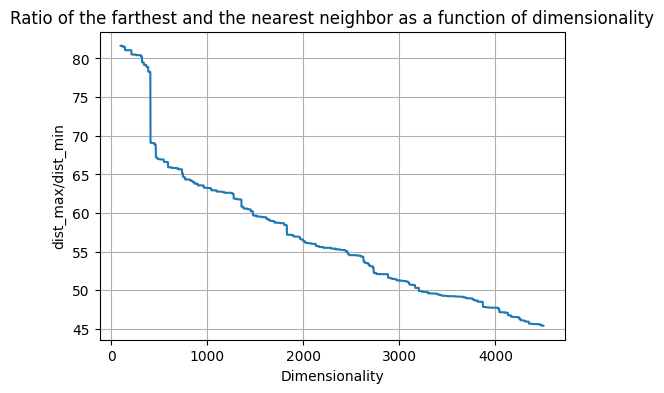

In [25]:
# plot dist_max/dist_min for different dimensionalities d:
plt.figure(figsize = (6,4))
start=100
indices = np.arange(start, len(distance_ratio)) #actual indices
plt.plot(indices, distance_ratio[start:])  # line plot with points
plt.xlabel("Dimensionality")
plt.ylabel("dist_max/dist_min")
plt.title("Ratio of the farthest and the nearest neighbor as a function of dimensionality")
plt.grid(True)
plt.show()

# Random projection (with theoretical guarantees)


### Johnson-Lindenstrauss lemma (distributional version)


 Let us have a fixed $0<\varepsilon<1$, and a fixed $0<\tau$, and a $d$-dimensional dataset that consists of $n$ samples. If $k$ satisfies

 $$k \geq (2+\tau)\frac{2\log(n)}{\varepsilon^2/2-\varepsilon^3/3}$$

then after a suitably scaled random projection of the dataset to a $k$-dimensional subspace, all of the distances between the points are distorted by no more than $\varepsilon$:

 $$ (1-\varepsilon)\|u-v\|_2 \leq \|P(u)-P(v)\|_2 \leq (1+\varepsilon)\|u-v\|_2 $$

with probability at least $1-\frac{1}{n^{\tau}}$.


See for example here https://ocw.mit.edu/courses/18-s096-topics-in-mathematics-of-data-science-fall-2015/f9261308512f6b90e284599f94055bb4_MIT18_S096F15_Ses15_16.pdf or here https://www.math.uci.edu/~rvershyn/papers/HDP-book/HDP-2.pdf (5.3 Application: Johnson-Lindenstrauss lemma)


That means that with a arbitrarily high probability (contolled by the parameter $\tau$) all the distances in our high-dimensional dataset are preserved up to a small distortion (controlled by the parameter $\varepsilon$) after a random projection to a lower dimension $k$.

That also means that if some points were concentrated in clusters in the original dimension, they will most probably be concentrated again after a random projection to a lower dimension, as long as we don't lower the dimensionality too much.

Constructing such a projection matrix is computationally very simple procedure that does not depend on the dataset, therefore it can be used for even for a dataset that we can not see at once (one that appears in a streaming fashion).

In [26]:
#construct the matrix that represents the orthogonal projection
#onto a random subspace of dimension k
d = 100 #dimension of the data
k = 40 #dimension of the subspace
np.random.seed(17)
P = np.random.randn(d, k)/np.sqrt(k)
print(P.shape)

(100, 40)


In [27]:
#project the data from the real (bio) sample:
num_samples = 250
d = 100 #should be the same as the fisrt dimension of matrix P
X_bio_centered = X_bio - X_bio.mean(axis=0, keepdims=True)
X_bio_centered_subsample = X_bio_centered[:250,:d]
print(X_bio_centered_subsample.shape)
X_bio_projected = np.dot(X_bio_centered_subsample, P)
print(X_bio_projected.shape)

(250, 100)
(250, 40)


In [28]:
# check the difference in distances between points in the original dataset
# and in the projected one:
trials = 10
compare_distances = np.zeros((trials,3))
for t in range(trials):
  i = np.random.randint(0, 250)
  j = np.random.randint(0, 250)
  compare_distances[t,0] = np.linalg.norm(X_bio_centered_subsample[i,:] - X_bio_centered_subsample[j,:])
  compare_distances[t,1] = np.linalg.norm(X_bio_projected[i,:] - X_bio_projected[j,:])
  if compare_distances[t,0] == 0:
    compare_distances[t,2] = 1
  else:
    compare_distances[t,2] = np.abs(compare_distances[t,1]/compare_distances[t,0]-1)
print(np.round(compare_distances[:,:2],2))
print('perturbation between the distances:')
print(np.round(compare_distances[:,2],2))


[[331.26 322.48]
 [ 97.51 104.56]
 [298.25 302.77]
 [155.52 166.53]
 [249.32 234.76]
 [188.75 184.07]
 [337.47 306.37]
 [409.71 379.56]
 [529.68 539.63]
 [563.98 554.58]]
perturbation between the distances:
[0.03 0.07 0.02 0.07 0.06 0.02 0.09 0.07 0.02 0.02]


### Random projection to extremely low dimensions to disrupt the original distance structure and reveal hidden clusters

What if we do not want to preserve the distances that exist in the original dimension? We discussed that in the high-dimensional data points become sparse compared to the empty spaces in between and often no cluster in the traditional sense can be identified. Therefore it may be beneficial to disrupt the distance structure so that after dimensionality reduction some clusters are identifiable.

We propose an alternative view on clustering and groupings: A New Model for Natural Groupings in High-Dimensional Data (https://link.springer.com/10.1007/978-3-032-03918-7_29). Instead of looking at points that are close together we explore the geometric structure of the data and find different semantic groupings based on different projections.  It provides a discrete counterpart to manifold learning and suggests ways to develop low-cost alternatives for existing methods.

Work was motivated by a large proportion of random projections to one dimension resulting in a bimodal distribution, although no clusters were observed in the original high-dimensional data.

Example of a bimodal distribution of the projected to one dimension high-dimensional data (MNIST dataset).
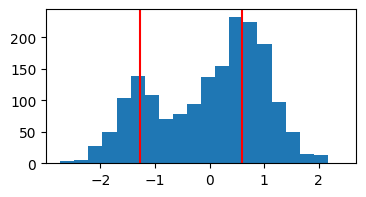

# Linear reduction friendly for interpretation

### PCA - Principal Component Analysis

Consider a dataset $\{x_i\}_{i=1}^n$.
Compute its empirical covariance matrix $$S_n = \frac{1}{n}\sum_{i=1}^{n}(x_i-\bar{x})(x_i-\bar{x})^T.$$
Matrix $S_n$ is positive semidefinite, therefore all of its eigenvalues are nonnegative. Let us choose the dimension for the reduction and denote it by $k$. Then find $k$ largest eigenvalues of $S_n$ by solving the following formula:
$$det(S_n-\lambda_iI_d)=0.$$
Find $k$ eigenvectors $e_i$ that correspond to the largest eigenvalues:
$$ S_n e_i = \lambda_i e_i.$$
These eigenvectors correspond to the directions in which our dataset is spread out the most. If we project the data onto the space spanned by them, we get a dimensionality reduction into a $k$-dimensional space that preserves in some sense the most information.

This method of dimensionality reduction is linear: it is based on a linear projection of the data onto the subspace spanned by the eigenvectors of the empirical covariance matrix.

#### Synthetic data

In [33]:
import numpy as np
#consider two datasets:
# let us start with Gaussian data - we will call it noise, because it's unstructured
d=10
num_samples = 500
np.random.seed(17)
data = np.random.multivariate_normal(np.zeros(d),np.eye(d), num_samples)

#let us add a "signal into the noise"
signal = np.zeros(d)
signal[0] = 1 #[1,0,0,...,0]
lamb = 5 #strength of the signal

np.random.seed(17)
pois = np.random.poisson(lam=lamb, size=(num_samples,1))
#we move each datapoint by a random value in the direction of the signal
#thus stretching data in that direction:
data_with_signal = data + (pois * signal)

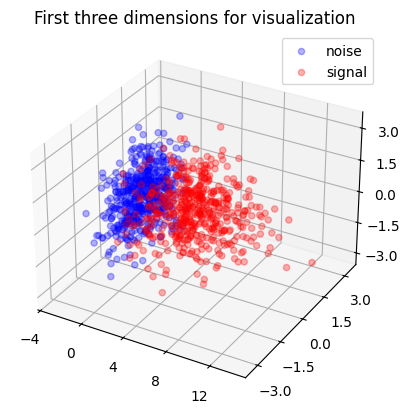

In [34]:
#visualize the first three dimensions of the original data and
# the data with an added signal:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(data[:, 0],
           data[:, 1],
           data[:, 2], color='blue', alpha=0.3, label="noise")

ax.scatter(data_with_signal[:, 0],
           data_with_signal[:, 1],
           data_with_signal[:, 2],
           color='red', alpha=0.3, label="signal")

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

ax.set_title('First three dimensions for visualization')
ax.legend()

plt.show()

In [35]:
from sklearn.decomposition import PCA
# for Gaussian data (noise):
pca_2_noise = PCA(n_components=2)
data_pca_2 = pca_2_noise.fit_transform(data)

# for data with signal
pca_2_signal = PCA(n_components=2)
data_with_signal_pca_2 = pca_2_signal.fit_transform(data_with_signal)

In [36]:
# we can compare principal components of the data and data with a signal
print('Principal eigenvalues - noise:',np.round(pca_2_noise.explained_variance_,2))
print('Explained variance ratio - noise:', np.round(pca_2_noise.explained_variance_ratio_,2)) # how much information each direction captures

print('Principal eigenvalues - signal:',np.round(pca_2_signal.explained_variance_,2))
print('Explained variance ratio - signal:', np.round(pca_2_signal.explained_variance_ratio_,2)) # how much information each direction captures


Principal eigenvalues - noise: [1.28 1.18]
Explained variance ratio - noise: [0.13 0.12]
Principal eigenvalues - signal: [6.54 1.27]
Explained variance ratio - signal: [0.42 0.08]


In [37]:
# is the vector that corresponds to the signal one of the principal components?
# normalized vectors
print(signal/np.linalg.norm(signal))

print(np.round(pca_2_signal.components_[0,:]/np.linalg.norm(pca_2_signal.components_[0,:]),2))

[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[ 1.   -0.01 -0.02 -0.   -0.    0.01  0.01  0.02  0.   -0.  ]


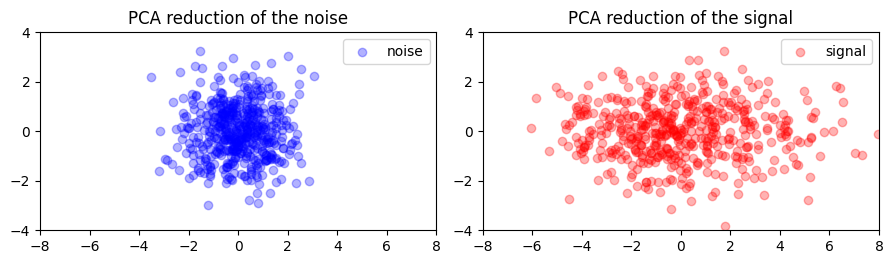

In [38]:
#visualize the original data and the data with an added signal after PCA reduction:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# First plot
axes[0].scatter(data_pca_2[:, 0],
                data_pca_2[:, 1],
                color='blue', alpha=0.3, label='noise')
axes[0].set_title("PCA reduction of the noise")

# Second plot
axes[1].scatter(data_with_signal_pca_2[:, 0],
             data_with_signal_pca_2[:, 1],
             color='red', alpha=0.3, label='signal')
axes[1].set_title("PCA reduction of the signal")


for ax in axes:
    ax.set_xlim(-8, 8)
    ax.set_ylim(-4, 4)
    ax.set_aspect('equal')
    ax.legend()

plt.tight_layout()

plt.legend()
plt.show()

#### Real data (Olivetti dataset)

In [39]:
# center the data - data should be centered, but not scaled (with respect to variance).

X_olivetti_flat_centered = X_olivetti_flat - X_olivetti_flat.mean(axis=0, keepdims=True)

In [40]:
# fit PCA
from sklearn.decomposition import PCA
pca_3 = PCA(n_components=3)
X_olivetti_pca_3 = pca_3.fit_transform(X_olivetti_flat_centered)

In [43]:
# Eigenvalues and eigenvectors
eigenvalues = pca_3.explained_variance_
eigenvectors = pca_3.components_

print('Principal eigenvalues:', np.round(pca_3.explained_variance_,2))
print('Explained variance ratio:', np.round(pca_3.explained_variance_ratio_,2)) # how much information each direction captures
print('Principal eigenvector:')
print(np.round(pca_3.components_, 4))
first_eigenvector = pca_3.components_[0]
#epsilon=0.1
#print(np.round(first_eigenvector[first_eigenvector>epsilon]))


Principal eigenvalues: [18.84 11.07  6.3 ]
Explained variance ratio: [0.24 0.14 0.08]
Principal eigenvector:
[[ 0.0042  0.0071  0.0093 ... -0.0002 -0.0034 -0.0032]
 [ 0.0286  0.0333  0.0378 ... -0.0296 -0.0272 -0.0249]
 [ 0.0014 -0.0003 -0.0002 ... -0.0154 -0.0137 -0.0119]]


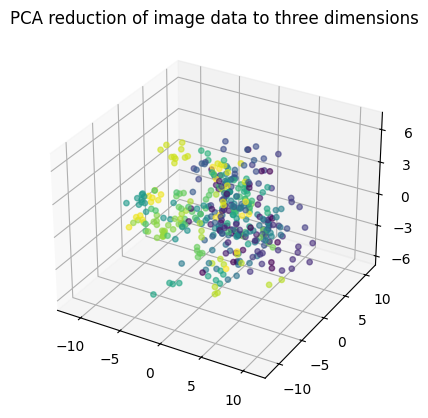

In [44]:
#Visualize the PCA reduction to 3 dimensions:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_olivetti_pca_3[:, 0],
           X_olivetti_pca_3[:, 1],
           X_olivetti_pca_3[:, 2], s=15,alpha=0.6, c=y_olivetti)

ax.set_title('PCA reduction of image data to three dimensions')

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

##### Cluster after PCA

In [45]:
#kmeans on reduced data:
from sklearn.cluster import KMeans

k = 40  # number of clusters (different persons)

kmeans = KMeans(n_clusters=k, random_state=17)
pca_kmeans_labels = kmeans.fit_predict(X_olivetti_pca_3)

In [46]:
#measure the quality of clustering by comparing to the true labels:

from sklearn.metrics import adjusted_rand_score

score = adjusted_rand_score(y_olivetti, pca_kmeans_labels)
print('Adjusted Rand score is', score)

Adjusted Rand score is 0.21142436817136553


#### Real data (bio)

In [47]:
print(X_bio.shape)

(1422, 4500)


In [48]:
# center the data - data should be centered, but not scaled (using StandardScaler).
n_features = 1602
#logaritm
X_bio_proc = X_bio[:,:n_features]
#X_bio_proc = np.log1p(X_bio[:,:n_features])
#center
X_bio_centered = X_bio_proc - X_bio_proc.mean(axis=0, keepdims=True)

In [49]:
# fit PCA
from sklearn.decomposition import PCA
pca_3 = PCA(n_components=3)
bio_pca_3 = pca_3.fit_transform(X_bio_centered)

In [50]:
# Eigenvalues and eigenvectors
eigenvalues = pca_3.explained_variance_
eigenvectors = pca_3.components_

print('Principal eigenvalues:', np.round(pca_3.explained_variance_,2))
print('Explained variance ratio:', np.round(pca_3.explained_variance_ratio_,2)) # how much information each direction captures
print('Principal eigenvectors:')
print(np.round(pca_3.components_[0],4))
first_eigenvector = pca_3.components_[0]
epsilon=0.1
print("# not too small components of this vector:")
print(np.round(first_eigenvector[first_eigenvector>epsilon],4))
print("sum of all entries:")
print(np.round(np.sum(first_eigenvector),4))


Principal eigenvalues: [222942.29  16953.62   4575.84]
Explained variance ratio: [0.88 0.07 0.02]
Principal eigenvectors:
[ 0.3419  0.0225  0.3043 ...  0.     -0.     -0.    ]
# not too small components of this vector:
[0.3419 0.3043 0.1773 0.6788 0.3018 0.4354]
sum of all entries:
2.627


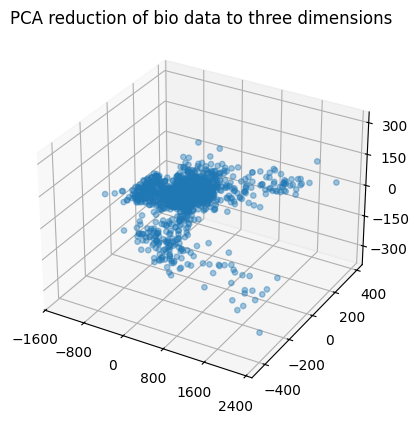

In [51]:
#Visualize the PCA reduction to 3 dimensions:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(bio_pca_3[:, 0], bio_pca_3[:, 1], bio_pca_3[:, 2], s=15,alpha=0.4)

ax.set_title('PCA reduction of bio data to three dimensions')

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

# Complex non-linear reductions


### Autoencoders


Using Neural network for dimensionality reduction - fitting a non-linear mapping into lower dimension.

Consists of encoder that encodes the data into a lower-dimesnional space (latent space) and decoder that expands the data back to its original dimension. It is trained to approximate the identity function $f(x)\approx x$. For dimensionality reduction we ignore decoder and use the trained encoder with the latent space dimension set to the desired dimension of reduction.

A sketch of a dense neural network we plan to train.

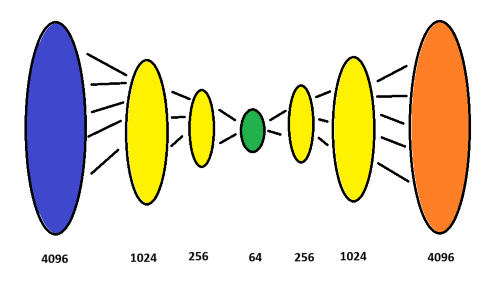

In [52]:
import tensorflow as tf
from tensorflow.keras import layers, Model

#### Olivetti dataset

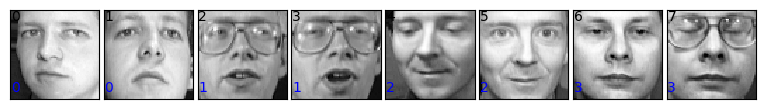

In [53]:
#visualize the dataset
import matplotlib.pyplot as plt

how_many = 8 #whole dataset has 400
fig = plt.figure(figsize=(60, 60))  # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)
for i in range(how_many):
    j=5*i+3
    ax = fig.add_subplot(64, 64, i + 1, xticks=[], yticks=[])
    ax.imshow(1-X_olivetti[j], cmap=plt.cm.binary, interpolation='nearest')
    # label the image with the target value
    ax.text(0, 58, str(y_olivetti[j]), c='blue')
    ax.text(0, 7, i)

In [63]:
#flatten the data:
X_olivetti_flat = X_olivetti.reshape((len(X_olivetti), -1))
print(X_olivetti_flat.shape)

(400, 4096)


In [64]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(X_olivetti_flat, test_size=0.2, random_state=17)

#standardize the training set and the test set
# better for the case of image dataset with a bounded values in each pixel
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [65]:
# set the input dimesnion for the NN as well as latent dimension
input_dim = X_train.shape[1]
latent_dim = 64 # we can plot the image in the latent dimension as 8x8
print(input_dim, latent_dim)

4096 64


In [66]:
import tensorflow as tf
from tensorflow.keras import layers, Model

# Encoder (4096 -> 1024 -> 256 -> 64 (latent dimension))
inputs = tf.keras.Input(shape=(input_dim,))
x = layers.Dense(1024, activation="relu")(inputs) #deeper network - progressive reduction of dimensions
x = layers.Dense(256, activation="relu")(x)
latent = layers.Dense(latent_dim)(x) #no activation

# Decoder (64 -> 256 ->1024 -> 4096 (original dimension))
x = layers.Dense(256, activation="relu")(latent)
x = layers.Dense(1024, activation="relu")(x)
outputs = layers.Dense(input_dim, activation="sigmoid")(x) #MinMax Scaler is paired with sigmoid activation

# Full autoencoder model
autoencoder = Model(inputs, outputs)

# Separate encoder model (for dimensionality reduction)
encoder = Model(inputs, latent)

# Compile
autoencoder.compile(optimizer="adam", loss="mse")

In [67]:
# Train (150 epochs 3m)
num_epochs = 150

#add early stopping - to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

#training
tf.random.set_seed(17)
history = autoencoder.fit(
    X_train, X_train,
    epochs=num_epochs,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[early_stop],
    verbose=1)

Epoch 1/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 223ms/step - loss: 0.0447 - val_loss: 0.0414
Epoch 2/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 140ms/step - loss: 0.0377 - val_loss: 0.0392
Epoch 3/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0345 - val_loss: 0.0354
Epoch 4/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 130ms/step - loss: 0.0316 - val_loss: 0.0338
Epoch 5/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 134ms/step - loss: 0.0305 - val_loss: 0.0326
Epoch 6/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.0286 - val_loss: 0.0288
Epoch 7/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 247ms/step - loss: 0.0255 - val_loss: 0.0272
Epoch 8/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 352ms/step - loss: 0.0243 - val_loss: 0.0263
Epoch 9/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - loss: 0.0230 - val_loss: 0.0239
Epoch 10/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 185ms/step - loss: 0.0213 - val_loss: 0.0226
Epoch 11/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step - loss: 0.0201 - val_loss: 0.0223
Epoch 12/150
10/10 ━━━━━━━━━━━━━━━━━━━━ 3

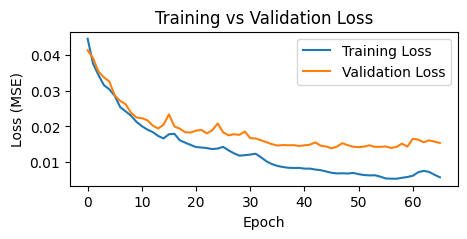

In [68]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(5,2))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [69]:
# Get reduced representation
X_autoencoder = encoder.predict(X_olivetti_flat)
print(X_autoencoder.shape)
dim = int(np.sqrt(X_autoencoder.shape[1]))
print(dim)
#X_autoencoder = X_autoencoder.reshape(X_autoencoder.shape[0], dim, dim)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
(400, 64)
8


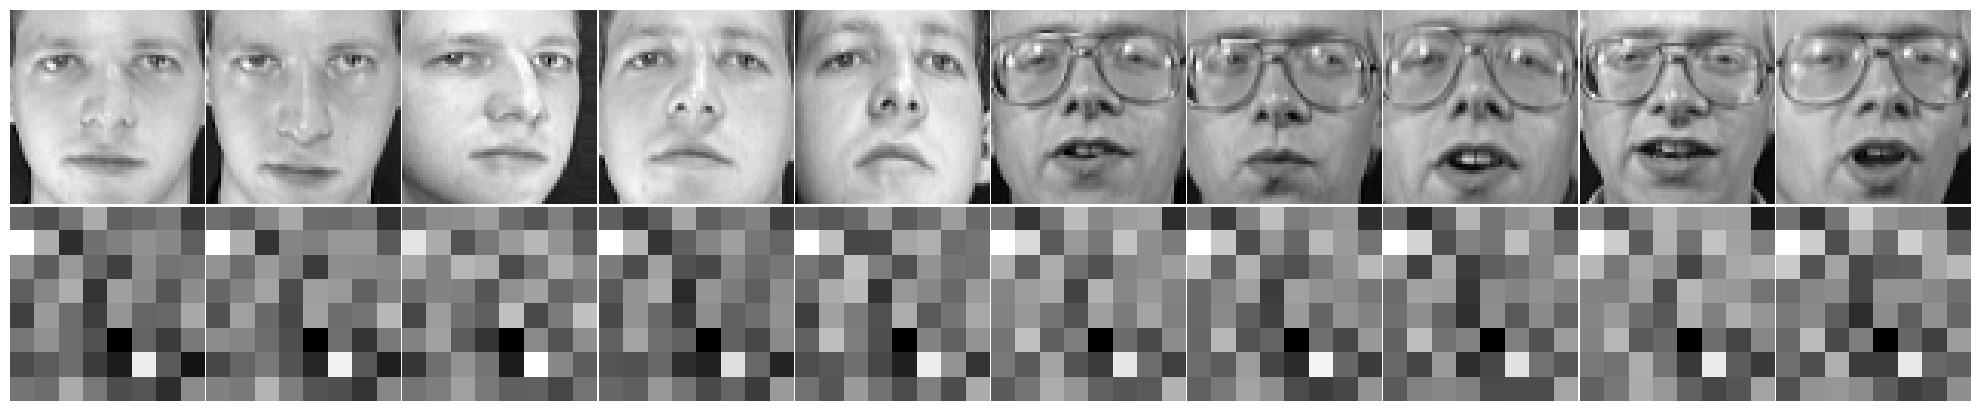

In [70]:
#compare original and reduced images
import matplotlib.pyplot as plt
import math

how_many = 10  # number of images to show
cols = how_many  # one column per image
rows = 2  # top: original, bottom: reconstructed

fig = plt.figure(figsize=(20, 4))  # wide and short
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99,
                    hspace=0.01, wspace=0.01)

for i in range(how_many):
    j = 2*i
    # Top row: original images
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.imshow(X_olivetti_flat[j].reshape(64, 64), cmap='gray', interpolation='nearest')
    ax.axis('off')

    # Bottom row: reconstructed images
    ax = fig.add_subplot(rows, cols, i + 1 + cols)
    ax.imshow(X_autoencoder[j].reshape(dim, dim), cmap='gray', interpolation='nearest')
    ax.axis('off')

plt.show()

In [71]:
#reconstruct images using the decoder:
X_reconstruction = autoencoder.predict(X_olivetti_flat)
print(X_reconstruction.shape)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
(400, 4096)


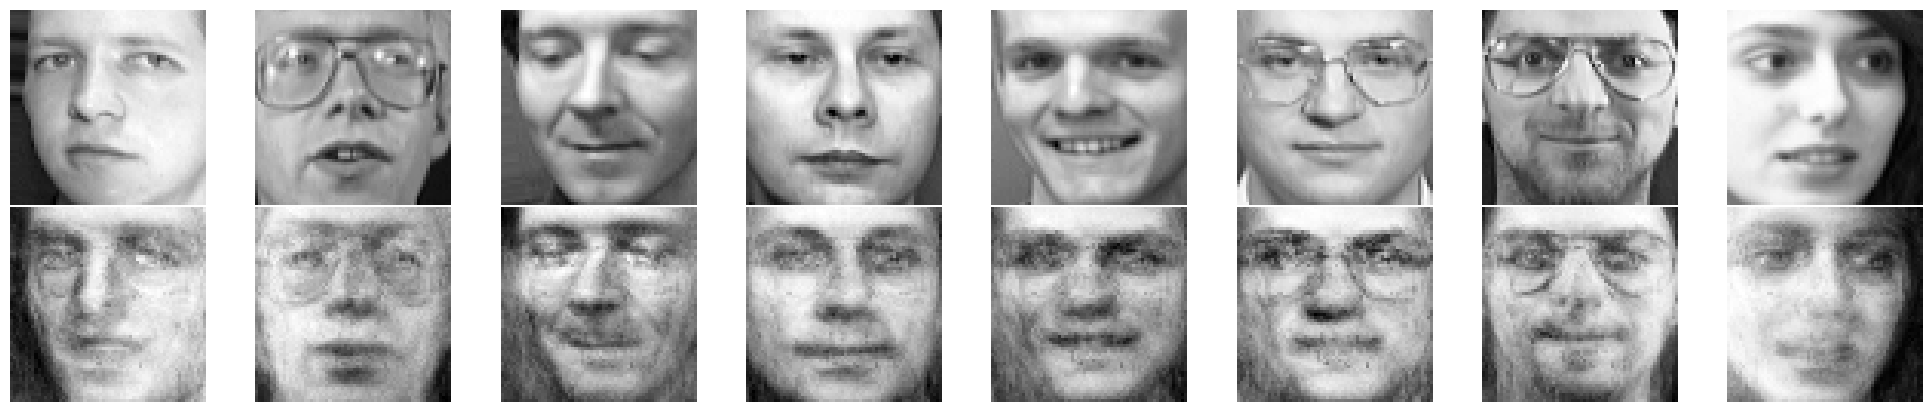

In [72]:
#compare original and reconstructed images
import matplotlib.pyplot as plt
import math

how_many = 8  # number of images to show
cols = how_many  # one column per image
rows = 2  # top: original, bottom: reconstructed

fig = plt.figure(figsize=(20, 4))  # wide and short
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.01, top=0.99,
                    hspace=0.01, wspace=0.01)

for i in range(how_many):
    # Top row: original images
    j=10*i+3
    ax = fig.add_subplot(rows, cols, i + 1)
    ax.imshow(X_olivetti_flat[j].reshape(64, 64), cmap='gray', interpolation='nearest')
    ax.axis('off')

    # Bottom row: reconstructed images
    ax = fig.add_subplot(rows, cols, i + 1 + cols)
    ax.imshow(X_reconstruction[j].reshape(64, 64), cmap='gray', interpolation='nearest')
    ax.axis('off')

plt.show()

#### Bio data

In [73]:
# preprocess the data - take a subset and standardize
num_samples = 1422
num_features = 64
bio_data_proc = X_bio[:num_samples,:num_features]

#log-transform the data -
#- distribution of counts in the genomic dataset is not close to Gaussian
#bio_data_proc = np.log1p(bio_data_proc) # log transform reduces large values and spreads out small ones
bio_data_proc = (bio_data_proc - bio_data_proc.mean()) / bio_data_proc.std() # standardize

In [74]:
print(bio_data_proc.shape)

(1422, 64)


In [75]:
input_dim = bio_data_proc.shape[1]
latent_dim = 16 # the dimension that we reduce to
print(input_dim, latent_dim)

64 16


In [76]:
# train test split
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(bio_data_proc, test_size=0.2, random_state=17)

#standardize the training set and the test set
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [77]:
# Encoder (64->32->16)
inputs = tf.keras.Input(shape=(input_dim,))
x = layers.Dense(32, activation="relu")(inputs)
latent = layers.Dense(latent_dim)(x) #no activation for the latent dimension

# Decoder (16->32->64)
x = layers.Dense(32, activation="relu")(latent)
outputs = layers.Dense(input_dim)(x) #Standard Scaler is paired with no activation

# Full autoencoder model
autoencoder = Model(inputs, outputs)

# Separate encoder model (for dimensionality reduction)
encoder = Model(inputs, latent)

# Compile
autoencoder.compile(optimizer="adam", loss="mse")
#optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4) #adjust the learning rate

In [78]:
# Train (600 epochs - 2m)
num_epochs = 600

#add early stopping - to prevent overfitting
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

#training
tf.random.set_seed(17)

history = autoencoder.fit(
    X_train, X_train,
    epochs=num_epochs,
    batch_size=32,
    shuffle=True,
    validation_data=(X_test, X_test),
    callbacks=[early_stop],
    verbose=1)

Epoch 1/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 1.0507 - val_loss: 0.9938
Epoch 2/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9481 - val_loss: 0.9174
Epoch 3/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.8514 - val_loss: 0.8025
Epoch 4/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7652 - val_loss: 0.7533
Epoch 5/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7298 - val_loss: 0.7311
Epoch 6/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7059 - val_loss: 0.7123
Epoch 7/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6843 - val_loss: 0.6949
Epoch 8/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6646 - val_loss: 0.6787
Epoch 9/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6466 - val_loss: 0.6642
Epoch 10/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6303 - val_loss: 0.6506
Epoch 11/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.6154 - val_loss: 0.6387
Epoch 12/600
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.

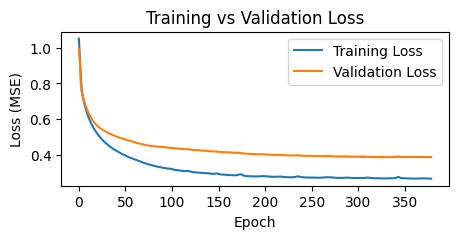

In [79]:
import matplotlib.pyplot as plt

# Plot
plt.figure(figsize=(5,2))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

In [80]:
# Get reduced representation
bio_data_autoencoder_3 = encoder.predict(bio_data_proc)
print(bio_data_autoencoder_3.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(1422, 16)


In [81]:
X_reconstruction = autoencoder.predict(bio_data_proc)
print(X_reconstruction.shape)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(1422, 64)


### GANs - Generative Adversarial network

Note: we can also use GANs for dimensionality reduction. GANs consist of two parts as well as Autoencoders: Generator and Discriminator. Generator generates high-dimensional samples that mimic the real data out of a low-dimensional noise. Discriminators take a high-dimensional sample as an input and output a single value that corresponds to a probability that the sample is fake. We can use the hidden layer output of the Discriminator for dimensionality reduction since its dimension is much smaller than the original one - and in some cases it gives meaningful results (see for example https://www.biorxiv.org/content/10.1101/262501v2.full).  

# Non-linear mapping for Visualization

###UMAP

Graph layout algorithm to arrange data in a low-dimensional space.  UMAP constructs a high dimensional graph representation of the data then optimizes a low-dimensional graph to be as structurally similar as possible to the high-dimensional one.

Fast algorithm that tends to preserve global structure of the data keeping similar clusters close to each other.

Two parameters are of the most importance: n_neighbors, which is an estimate of how many close neighbors points have to construct the initial high-dimensional graph. The second one is min_dist, which corresponds to the minimum distance between the points in the low-dimensional space.

Original paper at https://joss.theoj.org/papers/10.21105/joss.00861.

UMAP relies on meaningful distance metric,  nearest neighbor graph.

#### Fun visualization:

*  UMAP ZOO illustration: https://duhaime.s3.amazonaws.com/apps/umap-zoo/index.html
Notice that after reduction from 3D to 2D we can ususally see all of the parts of the animals (for example legs, tails, horns and so on). While most of linear projections would hide some features from us (for example we can only see two legs from the side).

#### Olivetti

In [82]:
#UMAP reduction (18s-51s)
import umap

# expect 9 close neighbors, because each person has 10 versions, low minimal distance
reducer = umap.UMAP(n_components=3, n_neighbors = 9, min_dist=0.0001, random_state=17)

# flatten the data, apply the reducer
X_olivetti_flat = X_olivetti.reshape((len(X_olivetti), -1))
X_olivetti_umap = reducer.fit_transform(X_olivetti_flat)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


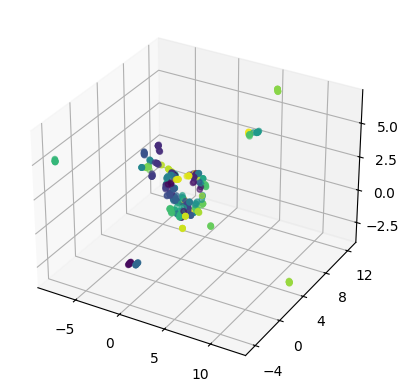

In [83]:
#3d visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_olivetti_umap[:,0],
           X_olivetti_umap[:,1],
           X_olivetti_umap[:,2],
           s=15,alpha=0.6,
           c=y_olivetti) #color base on the true label

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

Let us cluster the reduced data into 40 clusters (number of people represented in the images). UMAP disrupts distances so it is not recommended for clustering - given the discussion in the beginning, it might not be an inapropriate decision.

In [86]:
#cluster the data - after UMAP (using k-means)
from sklearn.cluster import KMeans

k = 40  # number of clusters (same as number of people in the set)

kmeans = KMeans(n_clusters=k, random_state=17)
umap_kmeans_labels_olivetti = kmeans.fit_predict(X_olivetti_umap)

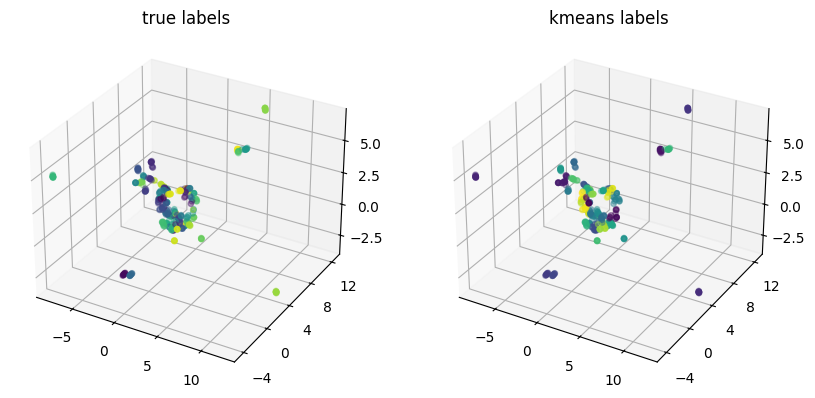

In [88]:
#visualize the clusters
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 5))

# labels - true labels
ax1 = fig.add_subplot(1, 2,1, projection='3d')
ax1.scatter(
    X_olivetti_umap[:, 0],
    X_olivetti_umap[:, 1],
    X_olivetti_umap[:, 2],
    c=y_olivetti,
    s=15,
    alpha=0.4
)
ax1.set_title("true labels")

# labels - kmeans clustering
ax2 = fig.add_subplot(1, 2,2, projection='3d')
ax2.scatter(
    X_olivetti_umap[:, 0],
    X_olivetti_umap[:, 1],
    X_olivetti_umap[:, 2],
    c=umap_kmeans_labels_olivetti,
    s=15,
    alpha=0.4
)
ax2.set_title("kmeans labels")

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
for ax in [ax1, ax2]:
  ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
  ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
  ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

In [118]:
#measure quality of clustering using unsupervised metrics
from sklearn.metrics import silhouette_score

score = silhouette_score(X_olivetti_umap, umap_kmeans_labels_olivetti) #1good
print('silhouette score is', score)

from sklearn.metrics import davies_bouldin_score

score = davies_bouldin_score(X_olivetti_umap, umap_kmeans_labels_olivetti)#0good, measures overlap
print('Davies Bouldin score is', score)

silhouette score is 0.64775217
Davies Bouldin score is 0.4867587679784517


In [90]:
# compare Adjusted Rand Index for kmeans after umap and true labels:
from sklearn.metrics import adjusted_rand_score

#1 complete agreement, 0 random agreement, <0 worse than random (0.54 is moderate agreement)
print("kmeans after umap compared with the true labels:",
      adjusted_rand_score(umap_kmeans_labels_olivetti, y_olivetti))

kmeans after umap compared with the true labels: 0.5420651209832743


In [91]:
# what labels are assigned to each person
full_row = 0
for i in range(40):
  values, counts = np.unique(umap_kmeans_labels_olivetti[10*i:10*(i+1)], return_counts=True)
  most_common = values[np.argmax(counts)]
  proportion = np.sum(umap_kmeans_labels_olivetti[10*i:10*(i+1)]==most_common)/10
  if proportion>=0.8:
    full_row += 1
  print('person',i,'prop',proportion, 'label', umap_kmeans_labels_olivetti[10*i:10*(i+1)])
print('almost completely recognized:',full_row)

person 0 prop 0.4 label [31 35 31 11  0 11 31 24 31  0]
person 1 prop 1.0 label [7 7 7 7 7 7 7 7 7 7]
person 2 prop 0.3 label [ 9  9  9 17 17 33 37 37 38 38]
person 3 prop 0.4 label [15 15 15 39 39 11 12 15 36 39]
person 4 prop 0.5 label [29 29 29 29 37 37 29 37 37 22]
person 5 prop 1.0 label [13 13 13 13 13 13 13 13 13 13]
person 6 prop 0.7 label [28 28 24 28 28 24 28 28 24 28]
person 7 prop 0.6 label [16 16 16 35 16 16 35 16 11 35]
person 8 prop 0.7 label [14 34 34 14 14 14 19 14 14 14]
person 9 prop 0.8 label [38 38 38 38 38 38 38 38 11 16]
person 10 prop 1.0 label [21 21 21 21 21 21 21 21 21 21]
person 11 prop 0.5 label [ 0 34 34 34 34 24 34  0  0  0]
person 12 prop 0.5 label [15 15 19 19 15 39 17 17 15 15]
person 13 prop 1.0 label [8 8 8 8 8 8 8 8 8 8]
person 14 prop 0.5 label [36 15 36 36 15 36 15 36 15 15]
person 15 prop 0.5 label [30 31 31 39 39 30 39 31 31 31]
person 16 prop 0.4 label [14 14  9  9 14 37 37 14 37 37]
person 17 prop 0.6 label [39 39 24 39 24 24 39 24 24 24]
pers

In [92]:
#cluster the original data - without UMAP
from sklearn.cluster import KMeans

k = 40  # number of clusters (same as number of people in the set)

kmeans = KMeans(n_clusters=k, random_state=17)
kmeans_labels = kmeans.fit_predict(X_olivetti_flat)

Better result of clustering after UMAP than on the original data, even though the distances are distorted.

In [95]:
print("kmeans compared with the true labels:", np.round(adjusted_rand_score(kmeans_labels, y_olivetti),4))
print("kmeans after umap compared with the true labels:", np.round(adjusted_rand_score(umap_kmeans_labels_olivetti, y_olivetti),4))

kmeans compared with the true labels: 0.4178
kmeans after umap compared with the true labels: 0.5421


#### Bio data

In [96]:
# preprocess the bio data
n_features = 1602
X_bio_proc = X_bio[:,:n_features]
#logaritm
#X_bio_proc = np.log1p(X_bio)
#standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_bio_proc = scaler.fit_transform(X_bio)

In [97]:
#UMAP reduction (1m, 24s, random state)
import umap

reducer = umap.UMAP(n_components=3, n_neighbors = 5, min_dist=0.1, random_state=17)

X_bio_umap = reducer.fit_transform(X_bio_proc)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


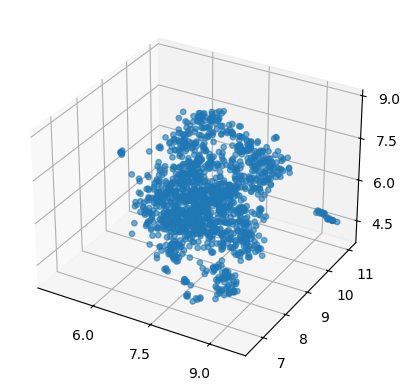

In [98]:
#3d visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_bio_umap[:, 0], X_bio_umap[:, 1], X_bio_umap[:, 2], s=15,alpha=0.6)

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()


### t-SNE

A non-linear mapping especially usefull for high-dimensional data that lie on several different low dimensional manifolds (such as images of objects from multiple classes seen from multiple viewpoints).

Includes a parameter called perplexity, that balances focus between local and global features of the data. It is essentially a guess about how many close neighbors points in the dataset tend to have. Should be set to a value between 5 and 50 according to the original paper.

Original paper can be found here: https://www.jmlr.org/papers/volume9/vandermaaten08a/vandermaaten08a.pdf

#### Additional resource:

*  How to Use t-SNE Effectively: https://distill.pub/2016/misread-tsne/
*  Comparison between UMAP and t-SNE:
https://pair-code.github.io/understanding-umap/

#### t-SNE on Olivetti dataset

In [99]:
from sklearn.manifold import TSNE #(4s for 100 lr, 7s for 300 lr)

tsne = TSNE(n_components=3, perplexity=9, learning_rate=300, random_state=17)

X_olivetti_tsne_3 = tsne.fit_transform(X_olivetti_flat)

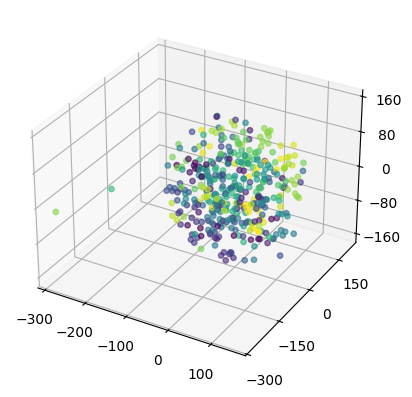

In [100]:
#3d visualization - we know that there are 40 people
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_olivetti_tsne_3[:, 0],
           X_olivetti_tsne_3[:, 1],
           X_olivetti_tsne_3[:, 2],
           s=15, alpha=0.6, c=y_olivetti)

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

In [101]:
#kmeans after tsne
from sklearn.cluster import KMeans

k = 40  # number of clusters (same as number of people in the set)

kmeans = KMeans(n_clusters=k, random_state=17)
tsne_kmeans_labels = kmeans.fit_predict(X_olivetti_tsne_3)

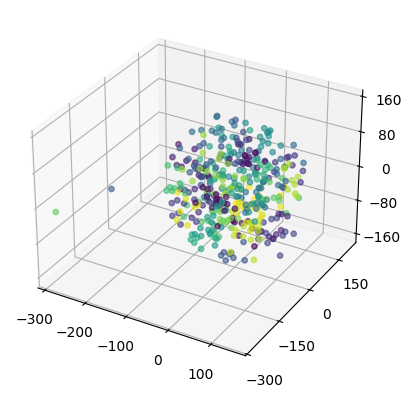

In [102]:
#3d visualization - we know that there are 40 people
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_olivetti_tsne_3[:, 0],
           X_olivetti_tsne_3[:, 1],
           X_olivetti_tsne_3[:, 2],
           s=15, alpha=0.6, c=tsne_kmeans_labels)

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

In [104]:
print("kmeans after tSNE compared with the true labels:", np.round(adjusted_rand_score(tsne_kmeans_labels, y_olivetti),4))
print("kmeans on original data compared with the true labels:", np.round(adjusted_rand_score(kmeans_labels, y_olivetti),4))
print("kmeans after umap compared with the true labels:", np.round(adjusted_rand_score(umap_kmeans_labels_olivetti, y_olivetti),4))

kmeans after tSNE compared with the true labels: 0.2703
kmeans on original data compared with the true labels: 0.4178
kmeans after umap compared with the true labels: 0.5421


#### t-SNE on bio data

In [105]:
# preprocess the bio data
n_features = 1602
X_bio_proc = X_bio[:,:n_features]
#logaritm
#X_bio_proc = np.log1p(X_bio)
#standard scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_bio_proc = scaler.fit_transform(X_bio)

In [106]:
#t-SNE reduction (2m 200 lr, 25s 100 lr)
from sklearn.manifold import TSNE

tsne = TSNE(n_components=3, perplexity=10, learning_rate=100, random_state=17)

X_bio_tsne_3 = tsne.fit_transform(X_bio_proc)

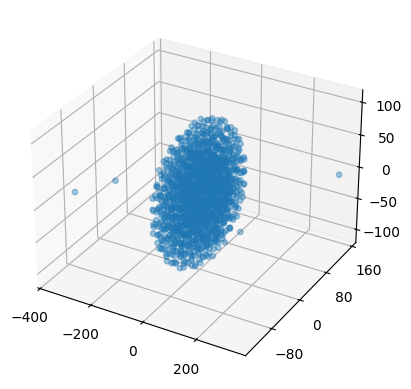

In [107]:
#3d visualization
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(X_bio_tsne_3[:, 0], X_bio_tsne_3[:, 1], X_bio_tsne_3[:, 2], s=15, alpha=0.4)

#control the ticks
from matplotlib.ticker import MaxNLocator
num_ticks=5
ax.xaxis.set_major_locator(MaxNLocator(num_ticks))
ax.yaxis.set_major_locator(MaxNLocator(num_ticks))
ax.zaxis.set_major_locator(MaxNLocator(num_ticks))

plt.show()

## Compare all clusterings after different reductions of bio dataset:

In [121]:
# apply kmeans to all of the reductions:
k = 4

kmeans = KMeans(n_clusters=k, random_state=17)

pca_kmeans_labels = kmeans.fit_predict(bio_pca_3)
auto_kmeans_labels = kmeans.fit_predict(bio_data_autoencoder_3)
umap_kmeans_labels = kmeans.fit_predict(X_bio_umap)
tsne_kmeans_labels = kmeans.fit_predict(X_bio_tsne_3)
kmeans_bio_labels = kmeans.fit_predict(X_bio_proc)

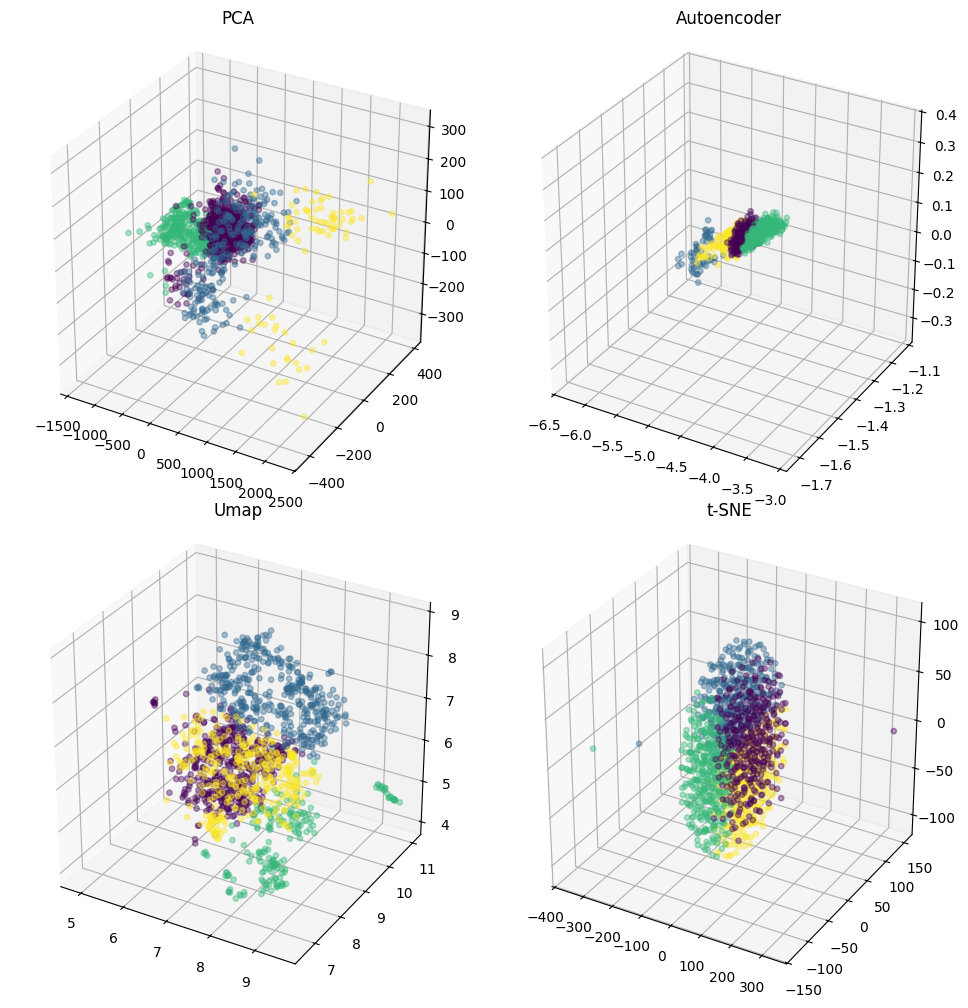

In [113]:
#first visually
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 10))

# pca
ax1 = fig.add_subplot(2, 2, 1, projection='3d')
ax1.scatter(bio_pca_3[:, 0], bio_pca_3[:, 1], bio_pca_3[:, 2],
            c=pca_kmeans_labels, s=15, alpha=0.4)
ax1.set_title("PCA")

# autoencoder
ax2 = fig.add_subplot(2, 2, 2, projection='3d')
ax2.scatter(bio_data_autoencoder_3[:, 0], bio_data_autoencoder_3[:, 1], bio_data_autoencoder_3[:, 2],
            c=auto_kmeans_labels, s=15, alpha=0.4)
ax2.set_title("Autoencoder")

# umap
ax3 = fig.add_subplot(2, 2, 3, projection='3d')
ax3.scatter(X_bio_umap[:, 0], X_bio_umap[:, 1], X_bio_umap[:, 2],
            c=umap_kmeans_labels, s=15, alpha=0.4)
ax3.set_title("Umap")

# tsne
ax4 = fig.add_subplot(2, 2, 4, projection='3d')
ax4.scatter(X_bio_tsne_3[:, 0], X_bio_tsne_3[:, 1], X_bio_tsne_3[:, 2],
            c=tsne_kmeans_labels, s=15, alpha=0.4)
ax4.set_title("t-SNE")

# same scale (optional)
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

In [110]:
#second using adjusted random score:

from sklearn.metrics import adjusted_rand_score

#1 complete agreement, 0 random agreement, <0 worse than random
# we compare the ageement in clustering of the cases after reduction is applied
# vs on original data
print("pca:", np.round(adjusted_rand_score(pca_kmeans_labels, kmeans_bio_labels),3))
print("autoencoder:", np.round(adjusted_rand_score(auto_kmeans_labels, kmeans_bio_labels),3))
print("umap:", np.round(adjusted_rand_score(umap_kmeans_labels, kmeans_bio_labels),3))
print("tsne:", np.round(adjusted_rand_score(tsne_kmeans_labels, kmeans_bio_labels),3))


pca: -0.001
autoencoder: -0.017
umap: -0.011
tsne: 0.025


In [122]:
# unsupervised metrics:

from sklearn.metrics import silhouette_score
#how similar is the point to its cluster:
#1 is good, 0 is overlapping clusters, <0 probably misassigned points
print('silhouette score')

print("pca silhouette score is", np.round(silhouette_score(bio_pca_3, pca_kmeans_labels),3))
print("autoencoder silhouette score is", np.round(silhouette_score(bio_data_autoencoder_3, auto_kmeans_labels),3))
print("umap silhouette score is", np.round(silhouette_score(X_bio_umap, umap_kmeans_labels),3))
print("tsne silhouette score is", np.round(silhouette_score(X_bio_tsne_3, tsne_kmeans_labels),3))

from sklearn.metrics import davies_bouldin_score
#ratio of within-cluster scatter to between cluster separation:
#0 ideal, <1 good

print('Davies Bouldin score')

print("pca Davies Bouldin score is", np.round(davies_bouldin_score(bio_pca_3, pca_kmeans_labels),3))
print("autoencoder Davies Bouldin score is", np.round(davies_bouldin_score(bio_data_autoencoder_3, auto_kmeans_labels),3))
print("umap Davies Bouldin score is", np.round(davies_bouldin_score(X_bio_umap, umap_kmeans_labels),3))
print("tsne Davies Bouldin score is", np.round(davies_bouldin_score(X_bio_tsne_3, tsne_kmeans_labels),3))


silhouette score
pca silhouette score is 0.416
autoencoder silhouette score is 0.484
umap silhouette score is 0.308
tsne silhouette score is 0.239
Davies Bouldin score
pca Davies Bouldin score is 0.769
autoencoder Davies Bouldin score is 0.69
umap Davies Bouldin score is 1.078
tsne Davies Bouldin score is 1.157


# Uploading datasets: an alternative way

In [ ]:
import numpy as np

### Iris dataset

In [ ]:
X_iris = np.load("X_iris.npy")
y_iris = np.load("y_iris.npy")
print(X_iris.shape)

(150, 4)


### Olivetti faces

In [ ]:
X_olivetti = np.load("olivetti_data.npy")
y_olivetti = np.load("olivetti_labels.npy")
print(X_olivetti.shape)

(400, 64, 64)


### Gene Expression Omnibus

In [ ]:
X_bio = np.load("bio_data.npy")
print(X_bio.shape)

(1422, 4500)
